In [1]:
# ライブラリのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# PATHの設定
#dir_path = '/content/drive/MyDrive/datascience-for-beginner/archive_EV'
dir_path = '/content/drive/MyDrive/datascience-for-beginner/archive_EV/'

#df = pd.read_csv(dir_path + 'AI_Learner_EV_Dataset_Pro.csv')
df = pd.read_csv(dir_path + 'AI_Learner_EV_Dataset_Pro.csv')


In [6]:
df.head()

,Brand,Model,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,Seats,PriceEuro,Price_Per_Range,Energy_Rating
0,Audi,e-tron 50 quattro,6.8,190,280,231,450,Yes,AWD,Type 2 CCS,SUV,E,5,67358,240.56,High Consumption
1,Tesla,Cybertruck Dual Motor,5.0,190,460,261,710,Yes,AWD,Type 2 CCS,Pickup,N,6,55000,119.57,High Consumption
2,Nissan,Ariya 87kWh,7.6,160,440,198,520,Yes,FWD,Type 2 CCS,Hatchback,C,5,50000,113.64,Average
3,Porsche,Taycan 4S,4.0,250,365,195,730,Yes,AWD,Type 2 CCS,Sedan,F,4,102945,282.04,Average
4,Audi,e-tron Sportback 55 quattro,5.7,200,380,228,610,Yes,AWD,Type 2 CCS,SUV,E,5,81639,214.84,High Consumption


In [7]:
print('データの大きさ:', df.shape)

データの大きさ: (103, 16)


In [9]:
df.dtypes

,0
Brand,object
Model,object
AccelSec,float64
TopSpeed_KmH,int64
Range_Km,int64
Efficiency_WhKm,int64
FastCharge_KmH,object
RapidCharge,object
PowerTrain,object
PlugType,object


In [10]:
#欠損値確認　== 欠損なし
df.isnull().sum()

,0
Brand,0
Model,0
AccelSec,0
TopSpeed_KmH,0
Range_Km,0
Efficiency_WhKm,0
FastCharge_KmH,0
RapidCharge,0
PowerTrain,0
PlugType,0


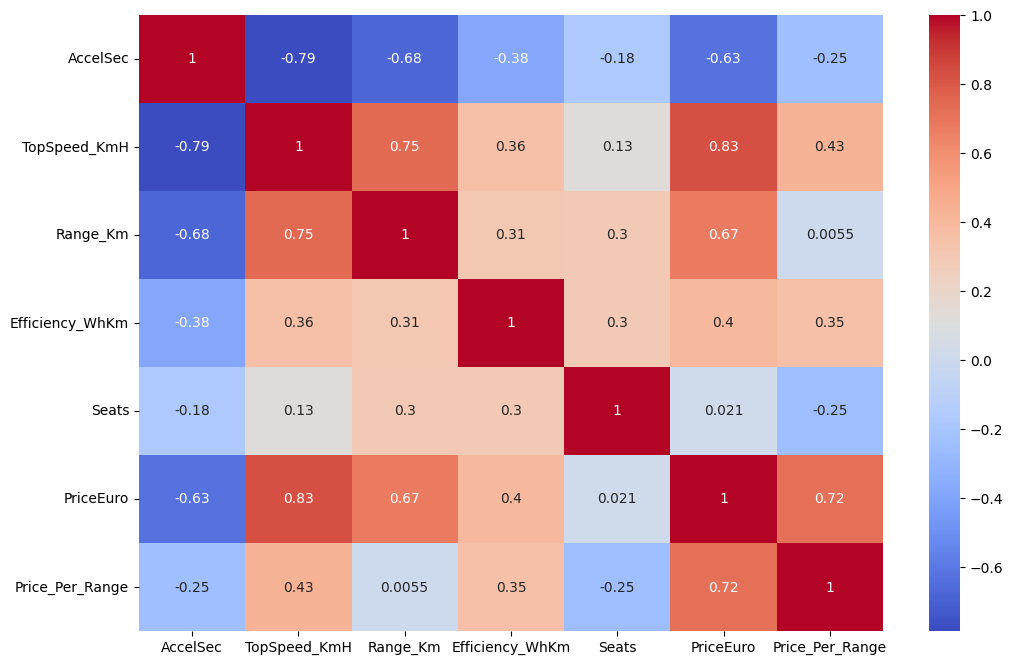

In [11]:
#相関関係を確認：ヒートマップ
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

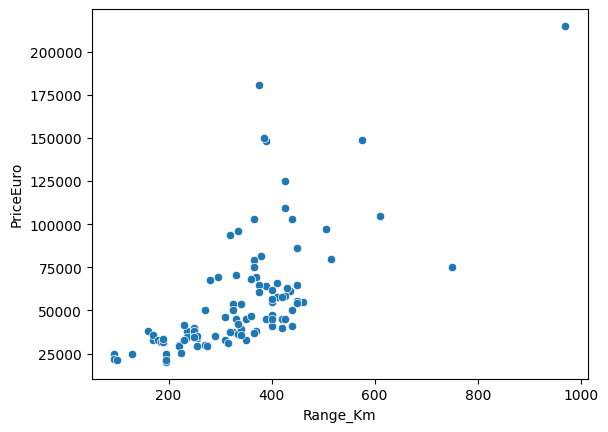

In [16]:
#価格とバッテリー容量の関係は？
sns.scatterplot(x=df["Range_Km"], y=df["PriceEuro"])
plt.show()


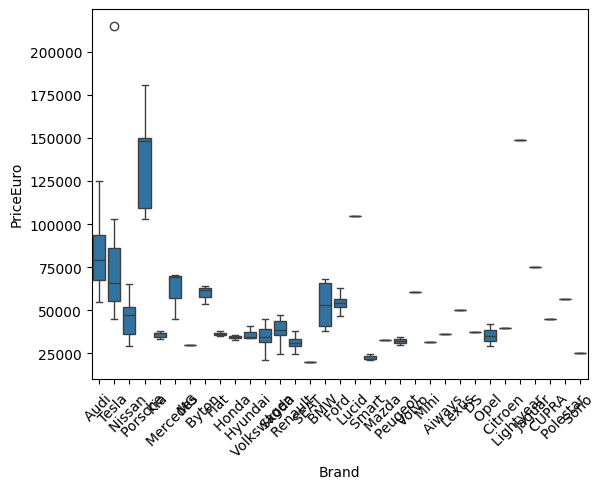

In [18]:
#ブランドと価格の関係
sns.boxplot(x=df["Brand"], y=df["PriceEuro"])
plt.xticks(rotation=45)
plt.show()

In [19]:
#特徴量エンジニアリング One-Hot Encoding (カテゴリデータ（文字やラベル）を機械学習で使える数値データに変換)
df = pd.get_dummies(df, drop_first=True)

In [22]:
#特徴量作成
df["km_per_Wh"] = df["Range_Km"] / df["Efficiency_WhKm"]
df["AccelPower"] = 1 / df["AccelSec"]
df["Range_per_Seat"] = df["Range_Km"] / df["Seats"]

In [30]:
#モデル作成　LightGBM(決定木を大量に組み合わせて賢く予測するモデル)を使用
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor

# データ前処理
df = df.drop(["Energy_Rating", "PlugType"], axis=1, errors="ignore")
df = df.drop("Model", axis=1, errors="ignore")

# 特徴量作成
df["Performance"] = df["TopSpeed_KmH"] / df["AccelSec"]
df["Efficiency_score"] = df["Range_Km"] / df["Efficiency_WhKm"]

# カテゴリ変換
df = pd.get_dummies(df, drop_first=True)

# 特徴量と目的変数
X = df.drop("PriceEuro", axis=1)
y = np.log1p(df["PriceEuro"])   # ← ここ重要（消さない！）

# 分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# モデル（上書きしない）
model = LGBMRegressor(
    n_estimators=200,
    num_leaves=15,
    min_data_in_leaf=1,
    min_gain_to_split=0
)

model.fit(X_train, y_train)


[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_gain_to_split is set=0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_gain_to_split is set=0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 606
[LightGBM] [Info] Number of data points in the train set: 82, number of used features: 189
[LightGBM] [Info] Start training from score 10.804420


LGBMRegressor(min_data_in_leaf=1, min_gain_to_split=0, n_estimators=200,
              num_leaves=15)

In [33]:
#評価
from sklearn.metrics import mean_squared_error
import numpy as np

pred_real = np.expm1(pred)
y_test_real = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
print("RMSE (Euro):", rmse)

RMSE (Euro): 7358.904283216658


In [34]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(10))

                         feature  importance
5                Price_Per_Range         294
2                       Range_Km         200
3                Efficiency_WhKm         154
1                   TopSpeed_KmH         134
215               Range_per_Seat         121
213                    km_per_Wh         109
0                       AccelSec         107
216                  Performance          72
214                   AccelPower          47
93   Model_Mustang Mach-E ER AWD          46


In [35]:
df = df.drop("Price_Per_Range", axis=1)

In [38]:
#評価
# ② 特徴量・目的変数
X = df.drop("PriceEuro", axis=1)
y = np.log1p(df["PriceEuro"])

# ③ 分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ④ モデル再作成＆再学習
model = LGBMRegressor(
    n_estimators=200,
    num_leaves=15,
    min_data_in_leaf=1,
    min_gain_to_split=0
)

model.fit(X_train, y_train)

# ⑤ 予測し直し
pred = model.predict(X_test)

# ⑥ 評価
pred_real = np.expm1(pred)
y_test_real = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
print("RMSE:", rmse)

[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_gain_to_split is set=0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_gain_to_split is set=0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 575
[LightGBM] [Info] Number of data points in the train set: 82, number of used features: 186
[LightGBM] [Info] Start training from score 10.824970
[LightGBM] [Warning] min_data_in_lea

In [39]:
#重要度分析
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(10))

             feature  importance
2           Range_Km         176
3    Efficiency_WhKm         170
1       TopSpeed_KmH         121
213       AccelPower         111
0           AccelSec         104
214   Range_per_Seat          84
212        km_per_Wh          73
65    Model_ID.3 1st          63
30       Brand_SEAT           50
115  Model_e Advance          50


In [40]:
#Model削除して再学習
# Model系削除（これ重要）
df = df[[col for col in df.columns if not col.startswith("Model_")]]

# 再作成
X = df.drop("PriceEuro", axis=1)
y = np.log1p(df["PriceEuro"])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LGBMRegressor(
    n_estimators=200,
    num_leaves=15,
    min_data_in_leaf=1,
    min_gain_to_split=0
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

# 評価
pred_real = np.expm1(pred)
y_test_real = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
print("RMSE:", rmse)

[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_gain_to_split is set=0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_gain_to_split is set=0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 82, number of used features: 104
[LightGBM] [Info] Start training from score 10.815321
[LightGBM] [Warning] min_data_in_lea

In [41]:
# 不要そうな列削除
drop_cols = [
    "Seats"
]

df = df.drop(drop_cols, axis=1, errors="ignore")

In [42]:
#Brandを圧縮
top_brands = df["Brand"].value_counts().nlargest(8).index
df["Brand"] = df["Brand"].apply(lambda x: x if x in top_brands else "Other")

KeyError: 'Brand'